In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EDA_data.csv to EDA_data (2).csv


In [ ]:
df= pd.read_csv("EDA_data.csv")

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0.0
1,15810944,Male,35.0,20000.0,0.0
2,15668575,Female,26.0,43000.0,0.0
3,15603246,Female,27.0,57000.0,0.0
4,15804002,Male,19.0,76000.0,0.0


In [ ]:
df.shape

(400, 5)

In [ ]:
df.size


2000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           371 non-null    object 
 2   Age              365 non-null    float64
 3   EstimatedSalary  369 non-null    float64
 4   Purchased        369 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,365.000000,369.000000,369.000000
mean,1.569154e+07,38.405479,71368.563686,0.357724
std,7.165832e+04,10.489659,33959.929846,0.479981
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,31.000000,46000.000000,0.000000
50%,1.569434e+07,38.000000,71000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


It shows information only for numerical data only

<Axes: xlabel='Purchased'>

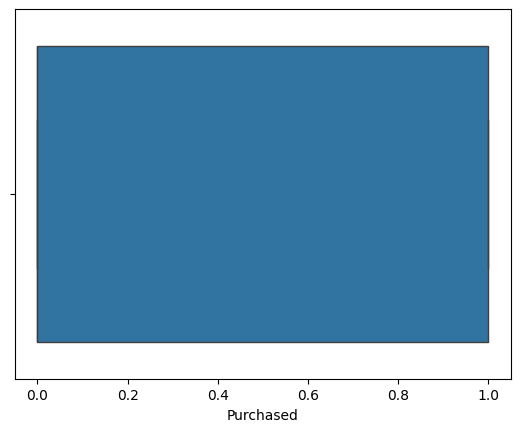

In [ ]:
sns.boxplot(x=df["Purchased"],orient='h')

<Axes: xlabel='Age'>

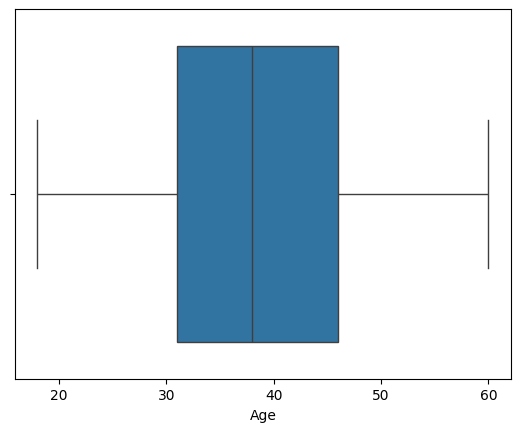

In [ ]:
sns.boxplot(x=df["Age"],orient='h')

**Missing Value imputation**

In [ ]:
df.isnull().sum() # tells how much missing values are there column wise

,0
User ID,0
Gender,29
Age,35
EstimatedSalary,31
Purchased,31


slecting and working on numerical data

In [ ]:
df1=df.select_dtypes(include=['int64','float64'])
df1

,User ID,Age,EstimatedSalary,Purchased
0,15624510,19.0,19000.0,0.0
1,15810944,35.0,20000.0,0.0
2,15668575,26.0,43000.0,0.0
3,15603246,27.0,57000.0,0.0
4,15804002,19.0,76000.0,0.0
...,...,...,...,...
395,15691863,46.0,41000.0,1.0
396,15706071,51.0,23000.0,1.0
397,15654296,50.0,20000.0,1.0
398,15755018,36.0,33000.0,0.0


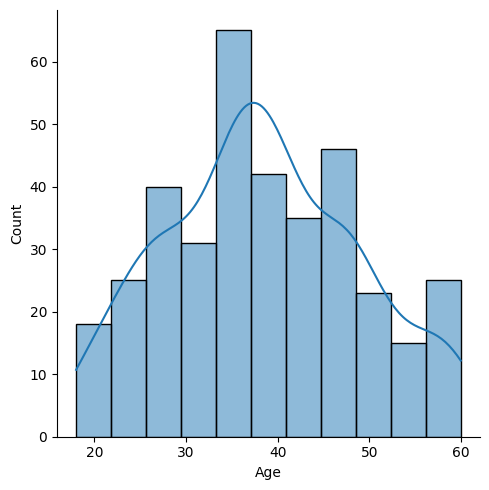

In [ ]:
sns.displot(df1['Age'],kde=True)


/tmp/ipykernel_1382/2823839677.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[var],bins=20,kde={'linewidth':5,'color':'r'})
/tmp/ipykernel_1382/2823839677.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[var],bins=20,kde={'linewidth':5,'color':'r'})
/tmp/ipykernel_1382/2823839677

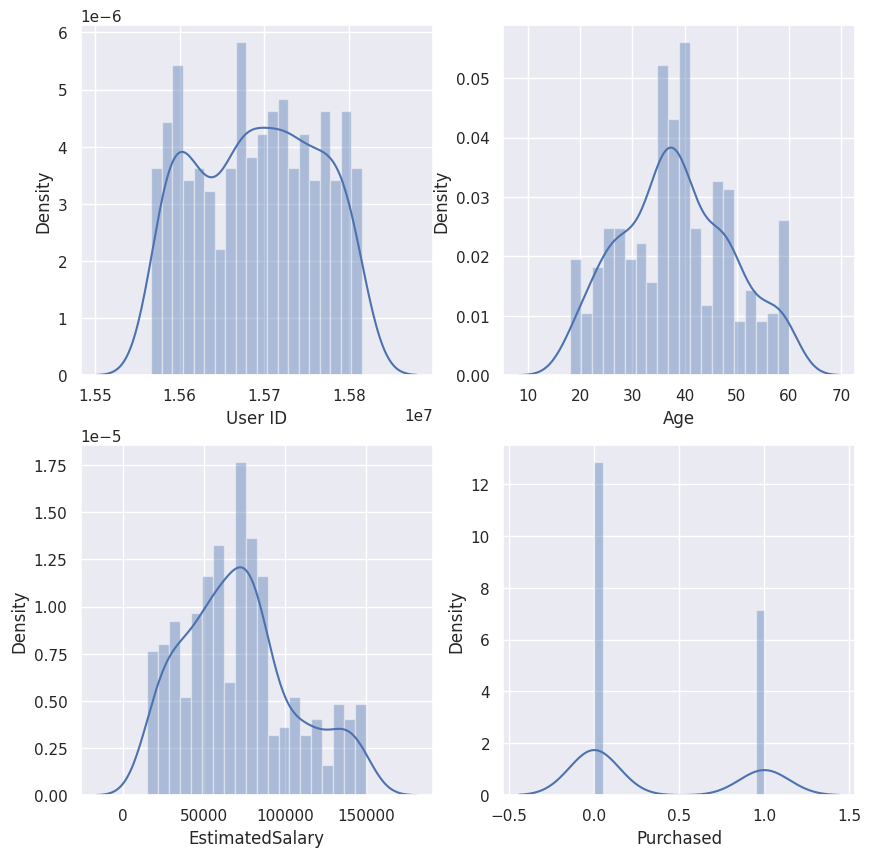

In [ ]:
plt.figure(figsize=(10,10))
sns.set()
for i , var in enumerate(df1):
  plt.subplot(2,2,i+1)
  sns.distplot(df1[var],bins=20,kde={'linewidth':5,'color':'r'})

# Age distribution is normal so it will be filled using mean

In [ ]:
df1['Age']=df1['Age'].fillna(df1['Age'].mean())

## Estimated Salary and Purchased distribution are not normal so it will be filled using median

In [ ]:
df1['EstimatedSalary']=df1['EstimatedSalary'].fillna(df1['EstimatedSalary'].median())
df1['Purchased']=df1['Purchased'].fillna(df1['Purchased'].median())

In [80]:
df1.isnull().sum()

,0
User ID,0
Age,0
EstimatedSalary,0
Purchased,0


# **Working on Categorical data**




In [78]:
df2=df.select_dtypes(include='object')
df2.head(2)

,Gender
0,Male
1,Male


In [79]:
df['Gender'].value_counts()

,count
Gender,
Female,191
Male,180


In [75]:
df2['Gender']=df2['Gender'].fillna(df2['Gender'].mode()[0])
df2.isnull().sum()

,0
Gender,0


In [76]:
df.to_csv("EDA_change.csv")

In [77]:
import os
os.getcwd()

'/content'

Columns of the Dataset are called as Variables

What are Continous Variable and Discreate Variable

Continous = with floats

discreat = non floats items